# Advanced Regression usig Gradient Descent

In [35]:
# importing the requisite libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Reading data

In [36]:
df = pd.read_csv("advertising.csv")

In [3]:
# df.to_csv('advertising.csv')

In [37]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,0,230.1,37.8,69.2,22.1
1,1,44.5,39.3,45.1,10.4
2,2,17.2,45.9,69.3,12.0
3,3,151.5,41.3,58.5,16.5
4,4,180.8,10.8,58.4,17.9
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7.6
196,196,94.2,4.9,8.1,14.0
197,197,177.0,9.3,6.4,14.8
198,198,283.6,42.0,66.2,25.5


In [5]:
data = df[["TV", "Sales"]]

In [6]:
data.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,12.0
3,151.5,16.5
4,180.8,17.9


In [11]:
df["TV"].corr(df["Sales"])

np.float64(0.9012079133023306)

### Building a linear regression model

In [39]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [ ]:
df["TV"]

In [17]:
# Splitting the dataset into X and y

X = np.array(data["TV"]).reshape(-1, 1)  # predictor variable
y = np.array(data["Sales"]).reshape(-1, 1)  # response variable

In [16]:
reg = LinearRegression()
reg.fit(df[["TV", "Radio"]], data["Sales"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Building the regression model
reg = LinearRegression()
reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = reg.predict(X)

In [20]:
r2_score(y, y_pred)

0.8121757029987414

In [21]:
from sklearn import metrics

metrics.r2_score(y, y_pred)

0.8121757029987414

In [22]:
metrics.mean_absolute_error(y, y_pred)

1.8305872641932417

In [23]:
metrics.mean_squared_error(y, y_pred)

5.2177438977951285

In [24]:
metrics.root_mean_squared_error(y, y_pred)

2.2842381438447106

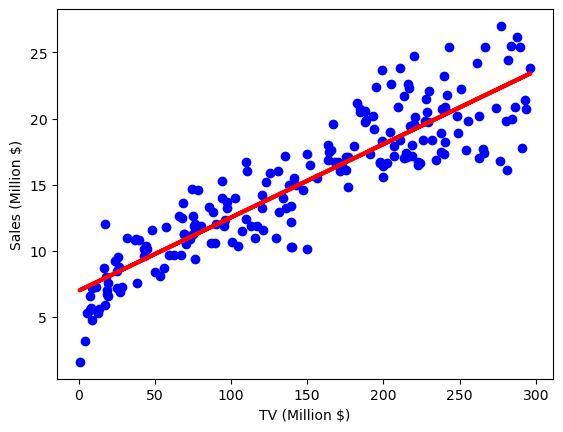

In [25]:
plt.scatter(X, y, color="blue")
plt.plot(X, y_pred, color="red", linewidth=3)
plt.xlabel("TV (Million $)")
plt.ylabel("Sales (Million $)")
plt.show()

In [26]:
rss = (y - y_pred) ** 2
rss = np.sum(rss)
rss

np.float64(1043.5487795590257)

In [27]:
# Mean Squared Error
mse = np.mean((y - y_pred) ** 2)
mse

np.float64(5.2177438977951285)

In [28]:
# Root Mean Squared Error
rmse = np.sqrt(mse)
rmse

np.float64(2.2842381438447106)

### Error Terms

In [29]:
# Metrics to assess model performance
rss = np.sum(
    np.square(y - y_pred)
)  # sum of the squared difference between the actual and the predicted values
print(rss)
mse = mean_squared_error(y, y_pred)  # MSE is RSS divided by the number of observations
print(mse)
rmse = (
    mse**0.5
)  # RMSE is square root of MSE i.e the predictions are different by this amount
print(rmse)

1043.5487795590257
5.2177438977951285
2.2842381438447106


### Normal Equations

#### Regression Equation
$\hat{y_i} = b_{0} + b_{1}{x_i}$<br>
where slope of trend line is calculated as:<br>
$b_{1}=\frac{\sum (x_i-\bar{x})*(y_i-\bar{y})}{\sum (x_i-\bar{x})^{2}}$<br>
and the intercept is computed as:<br>
$b_{0}=\bar{y}-b_{1}\bar{x}$

In [30]:
X = data["TV"].values
Y = data["Sales"].values

In [31]:
mean_X = np.mean(X)
mean_Y = np.mean(Y)
print(mean_X, mean_Y)
n = len(X)

147.0425 15.130500000000001


## Gradient Descent, finally,

In [32]:
# Gradient Descent for calculating coefficients
numerator, denominator = 0, 0
for i in range(n):
    numerator += (X[i] - mean_X) * (Y[i] - mean_Y)
    denominator += (X[i] - mean_X) ** 2
b1 = numerator / denominator
b0 = mean_Y - b1 * mean_X
print(f"b0 = {b0}, b1 = {b1}")

b0 = 6.974821488229903, b1 = 0.05546477046955879


### Linear Regression Model Estimates using Matrix Multiplications

$\widehat{\beta}=(X^{T}.X)^{-1}.X^{T}.Y$

In [33]:
x_mat = np.vstack((np.ones(len(X)), X)).T
x_mat[:5]

array([[  1. , 230.1],
       [  1. ,  44.5],
       [  1. ,  17.2],
       [  1. , 151.5],
       [  1. , 180.8]])

In [34]:
# Vectorization faster than loops
beta_hat = np.linalg.inv(x_mat.T.dot(x_mat)).dot(x_mat.T).dot(Y)
beta_hat

array([6.97482149, 0.05546477])

## Model Validity

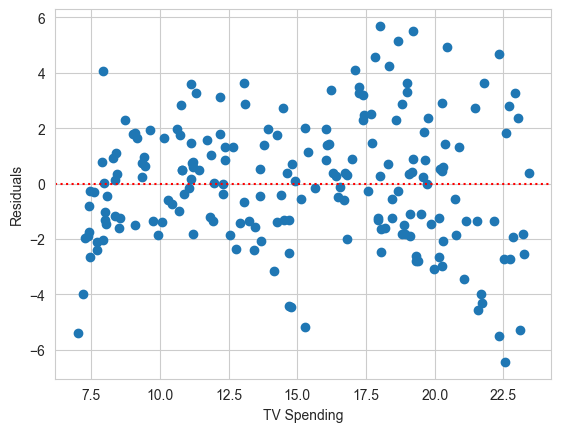

In [44]:
y_res = y - y_pred
df["res"] = y_res
plt.scatter(y_pred, df["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("TV Spending")
plt.ylabel("Residuals")
plt.show()

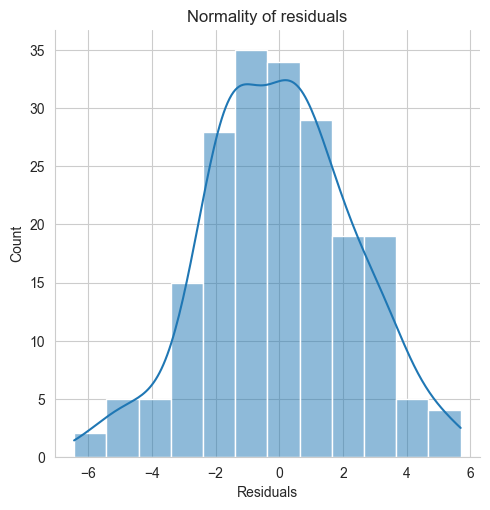

In [51]:
sns.displot(df["res"], kde=True)
plt.title("Normality of residuals")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()

## 1.2 Multi Linear Regerssion

In [54]:
df = pd.read_csv(
    "https://cdn.upgrad.com/UpGrad/temp/098bb2e9-83fb-48df-9dd1-fac56fbb25ca/advertising.csv"
)

In [55]:
df.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


### 1.2.1 EDA

<Axes: xlabel='TV', ylabel='Sales'>

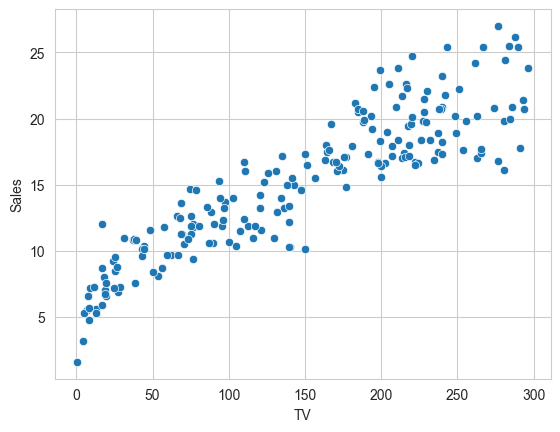

In [56]:
sns.scatterplot(df, x="TV", y="Sales")

<Axes: xlabel='Radio', ylabel='Sales'>

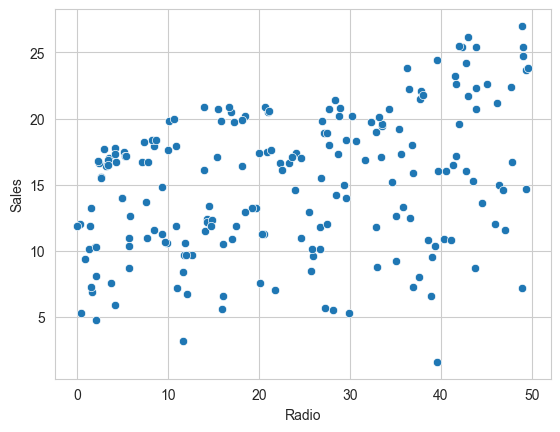

In [57]:
sns.scatterplot(df, x="Radio", y="Sales")

<Axes: xlabel='Newspaper', ylabel='Sales'>

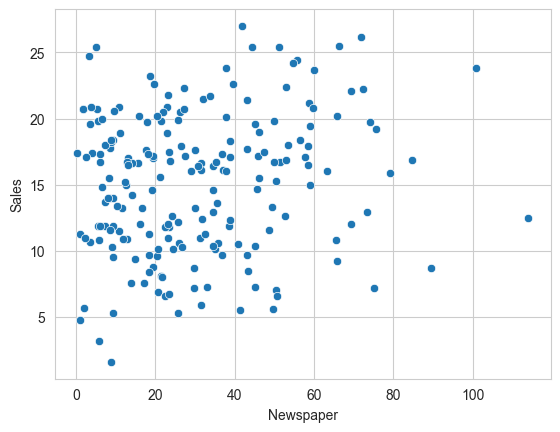

In [59]:
sns.scatterplot(df, x="Newspaper", y="Sales")

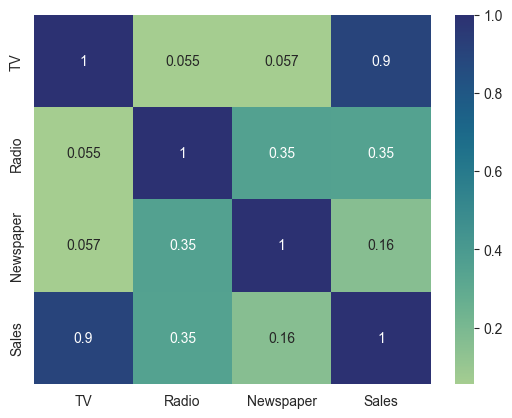

In [60]:
sns.heatmap(df.corr(), annot=True, cmap="crest")
plt.show()

In [90]:
dfModel = df.copy()
target = "Sales"
features = [col for col in dfModel if col != target]
X = dfModel[features]
y = dfModel[target]

In [91]:
lm = LinearRegression()
# Expecting error
lm.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
# X.shape

In [92]:
y_pred = lm.predict(X)

In [93]:
metrics.r2_score(y, y_pred)  # 1-RSS/TSS

0.9025912899684558

In [94]:
print(f"b1={lm.intercept_}")
print(f"b0={lm.coef_}")

b1=4.625124078808653
b0=[0.05444578 0.10700123 0.00033566]


In [100]:
# Metrics to assess model performance
rss = np.sum(
    np.square(y - y_pred)
)  # sum of the squared difference between the actual and the predicted values
print(rss)
mse = rss / X.shape[0]  # MSE is RSS divided by the number of observations
# or
mse_sk = metrics.mean_squared_error(y, y_pred)
print(mse, mse_sk)
rmse = mse**0.5  # RMSE is square root of MSE
print(rmse)

541.2012295254631
2.706006147627315 2.706006147627315
1.6449942697855562


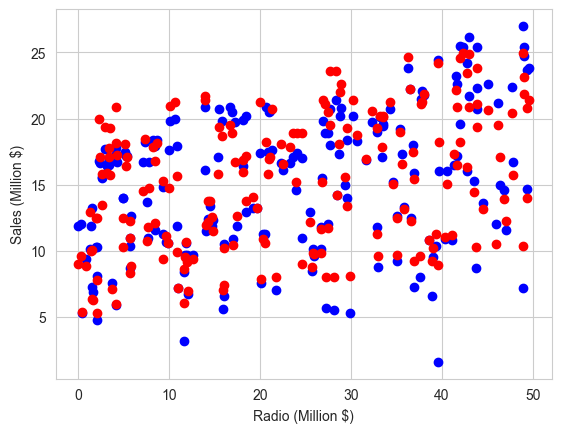

In [74]:
plt.scatter(X["Radio"], y, color="blue")
plt.scatter(X["Radio"], y_pred, color="red")
plt.xlabel("Radio (Million $)")
plt.ylabel("Sales (Million $)")
plt.show()

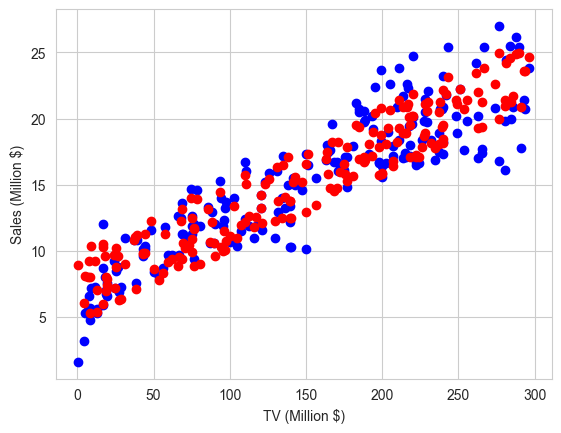

In [75]:
plt.scatter(X["TV"], y, color="blue")  # actual values
plt.scatter(X["TV"], y_pred, color="red")  # predicted values
plt.xlabel("TV (Million $)")
plt.ylabel("Sales (Million $)")
plt.show()

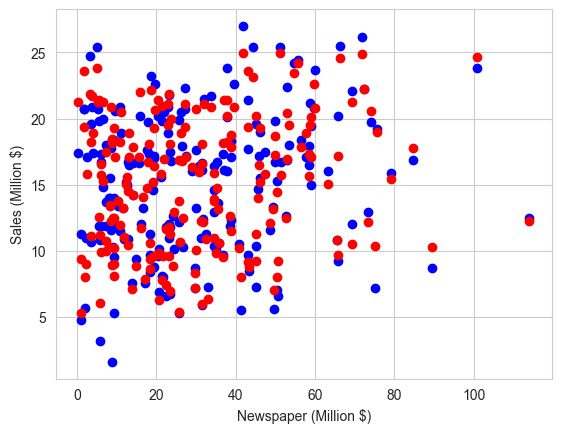

In [79]:
plt.scatter(X["Newspaper"], y, color="blue")  # actual values
plt.scatter(X["Newspaper"], y_pred, color="red")  # predicted values
plt.xlabel("Newspaper (Million $)")
plt.ylabel("Sales (Million $)")
plt.show()

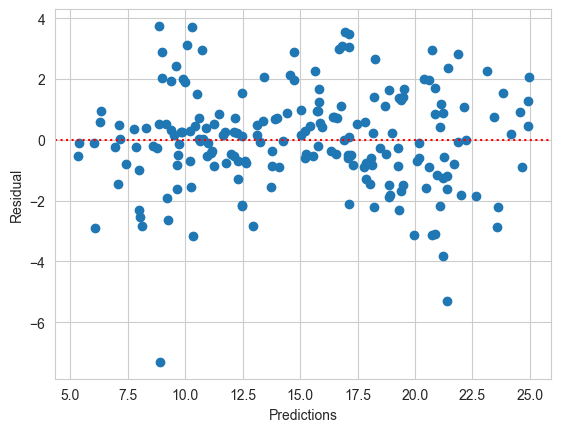

In [77]:
y_res = y - y_pred
dfModel["res"] = y_res
plt.scatter(y_pred, dfModel["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Predictions")
plt.ylabel("Residual")
plt.show()

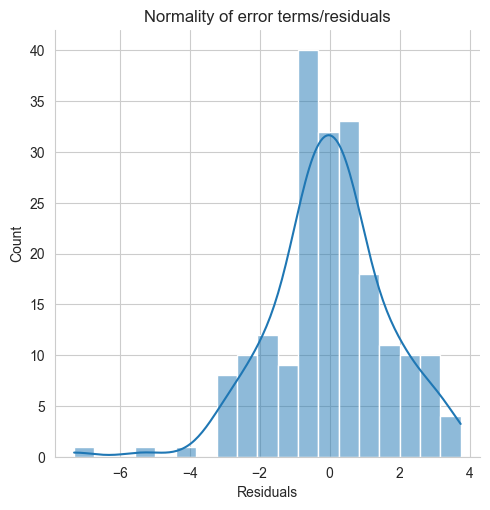

In [78]:
# Distribution of errors
p = sns.displot(y_res, kde=True)

p = plt.title("Normality of error terms/residuals")
plt.xlabel("Residuals")
plt.show()

## Using Matrices

In [82]:
x_mat = np.vstack((np.ones(len(X)), X.T)).T
x_mat

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5],
       [  1. , 180.8,  10.8,  58.4],
       [  1. ,   8.7,  48.9,  75. ],
       [  1. ,  57.5,  32.8,  23.5],
       [  1. , 120.2,  19.6,  11.6],
       [  1. ,   8.6,   2.1,   1. ],
       [  1. , 199.8,   2.6,  21.2],
       [  1. ,  66.1,   5.8,  24.2],
       [  1. , 214.7,  24. ,   4. ],
       [  1. ,  23.8,  35.1,  65.9],
       [  1. ,  97.5,   7.6,   7.2],
       [  1. , 204.1,  32.9,  46. ],
       [  1. , 195.4,  47.7,  52.9],
       [  1. ,  67.8,  36.6, 114. ],
       [  1. , 281.4,  39.6,  55.8],
       [  1. ,  69.2,  20.5,  18.3],
       [  1. , 147.3,  23.9,  19.1],
       [  1. , 218.4,  27.7,  53.4],
       [  1. , 237.4,   5.1,  23.5],
       [  1. ,  13.2,  15.9,  49.6],
       [  1. , 228.3,  16.9,  26.2],
       [  1. ,  62.3,  12.6,  18.3],
       [  1. , 262.9,   3.5,  19.5],
       [  1. , 142.9,  29.3,  12.6],
 

In [83]:
beta_hat = np.linalg.inv(x_mat.T.dot(x_mat)).dot(x_mat.T).dot(y)
beta_hat

array([4.62512408e+00, 5.44457803e-02, 1.07001228e-01, 3.35657922e-04])

In [84]:
beta_hat

array([4.62512408e+00, 5.44457803e-02, 1.07001228e-01, 3.35657922e-04])

In [102]:
lm.intercept_, lm.coef_

(np.float64(4.625124078808653),
 array([0.05444578, 0.10700123, 0.00033566]),
 {'copy_X': True,
  'fit_intercept': True,
  'n_jobs': None,
  'positive': False,
  'tol': 1e-06})

In [89]:
beta_hat_list = [float(x) for x in beta_hat]
coefficients = ["b0", "TV", "Radio", "Newspaper"]
dict(zip(coefficients, beta_hat_list))

{'b0': 4.625124078808671,
 'TV': 0.05444578033757087,
 'Radio': 0.10700122823870307,
 'Newspaper': 0.00033565792233050673}

In [104]:
0.4**2 + 0.3**2 + 0.1**2 + 0.1**2 + 0.3**2 + 0.1**2

0.37